In [27]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

First, we import the datasets from the ucimlrepo. 
We will then explore the data and wrangle/clean it if needed for the purposes of this project. 
We will mainly use pandas and matplotlib libraries to prepare and visualize the datasets. 

Let's start with the credit approval dataset. First, we will need to analyze the data to see if any cleaning or processing is needed to prepare for proper training and to have a general understanding of what the data consists of.

In [28]:
path = 'data/Credit/crx.data'
col_names = ['A'+str(i) for i in range(1, 16)] + ['class']
credit=pd.read_csv(path, names=col_names)
credit.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [29]:
X = credit.drop('class', axis=1)
y = credit['class']
credit.replace('?', np.nan, inplace=True)
X.isna().sum() 
y.isna().sum()  # no missing values

missing = X.isna()
print(missing.sum()) # 12 invalid values in A1, A2, and A14


y.describe()
y.unique() # '+' or '-' showing if they were approved or not



A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
dtype: int64


array(['+', '-'], dtype=object)

In [30]:
from sklearn.impute import SimpleImputer
#we'll handle the invalid values here by replacing them with the median of the cols


numeric = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
impute_median = SimpleImputer(strategy='median')

X[numeric] = impute_median.fit_transform(credit[numeric])
X.isna().sum() # missing non-int values 
X.dropna(inplace=True)
X.isna().sum() # no missing values now 
credit = pd.concat([X,y], axis = 1)
credit.head()
credit


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1.0,f,g,202.0,0.0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6.0,f,g,43.0,560.0,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0.0,f,g,280.0,824.0,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5.0,t,g,100.0,3.0,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0.0,f,s,120.0,0.0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0.0,f,g,260.0,0.0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2.0,t,g,200.0,394.0,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1.0,t,g,200.0,1.0,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0.0,f,g,280.0,750.0,-


to make it easier, we can change the + and - to 1 and -1.

In [31]:
credit['class'].replace({'+':1, '-':-1}, inplace=True)
credit.head()

/var/folders/ht/r1zv68tx79j04ckm359twg080000gn/T/ipykernel_43686/2865935736.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  credit['class'].replace({'+':1, '-':-1}, inplace=True)
/var/folders/ht/r1zv68tx79j04ckm359twg080000gn/T/ipykernel_43686/2865935736.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting'

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1.0,f,g,202.0,0.0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6.0,f,g,43.0,560.0,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0.0,f,g,280.0,824.0,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5.0,t,g,100.0,3.0,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0.0,f,s,120.0,0.0,1


In [32]:
# we'll encode the categorical values using one-hot encoding
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
categoric = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']
credit_encoded = pd.get_dummies(credit, columns=categoric, drop_first=True)
credit_encoded = credit_encoded.astype(int)
credit_encoded.head()
    

,A2,A3,A8,A11,A14,A15,class,A1_a,A1_b,A4_l,...,A7_j,A7_n,A7_o,A7_v,A7_z,A9_t,A10_t,A12_t,A13_p,A13_s
0,30,0,1,1,202,0,1,0,1,0,...,0,0,0,1,0,1,1,0,0,0
1,58,4,3,6,43,560,1,1,0,0,...,0,0,0,0,0,1,1,0,0,0
2,24,0,1,0,280,824,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,27,1,3,5,100,3,1,0,1,0,...,0,0,0,1,0,1,1,1,0,0
4,20,5,1,0,120,0,1,0,1,0,...,0,0,0,1,0,1,0,0,0,1


Now we have cleaned the data of invalid entries and have implemented one-hot-encoding. We'll explore it. 

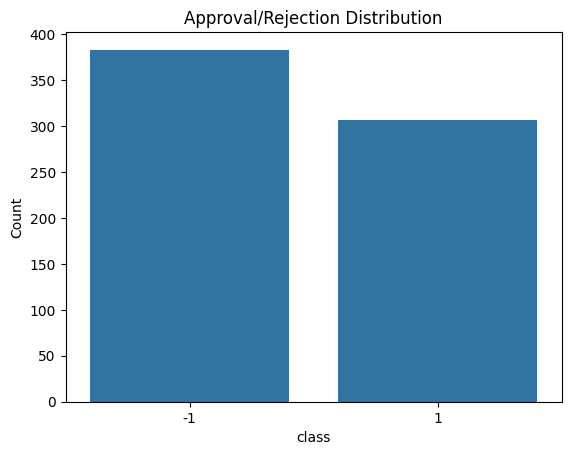

In [33]:
import seaborn as sns
sns.countplot(x='class', data=credit_encoded)
plt.title('Approval/Rejection Distribution')
plt.ylabel('Count')
plt.show()

This shows that more people were rejected than approved. 


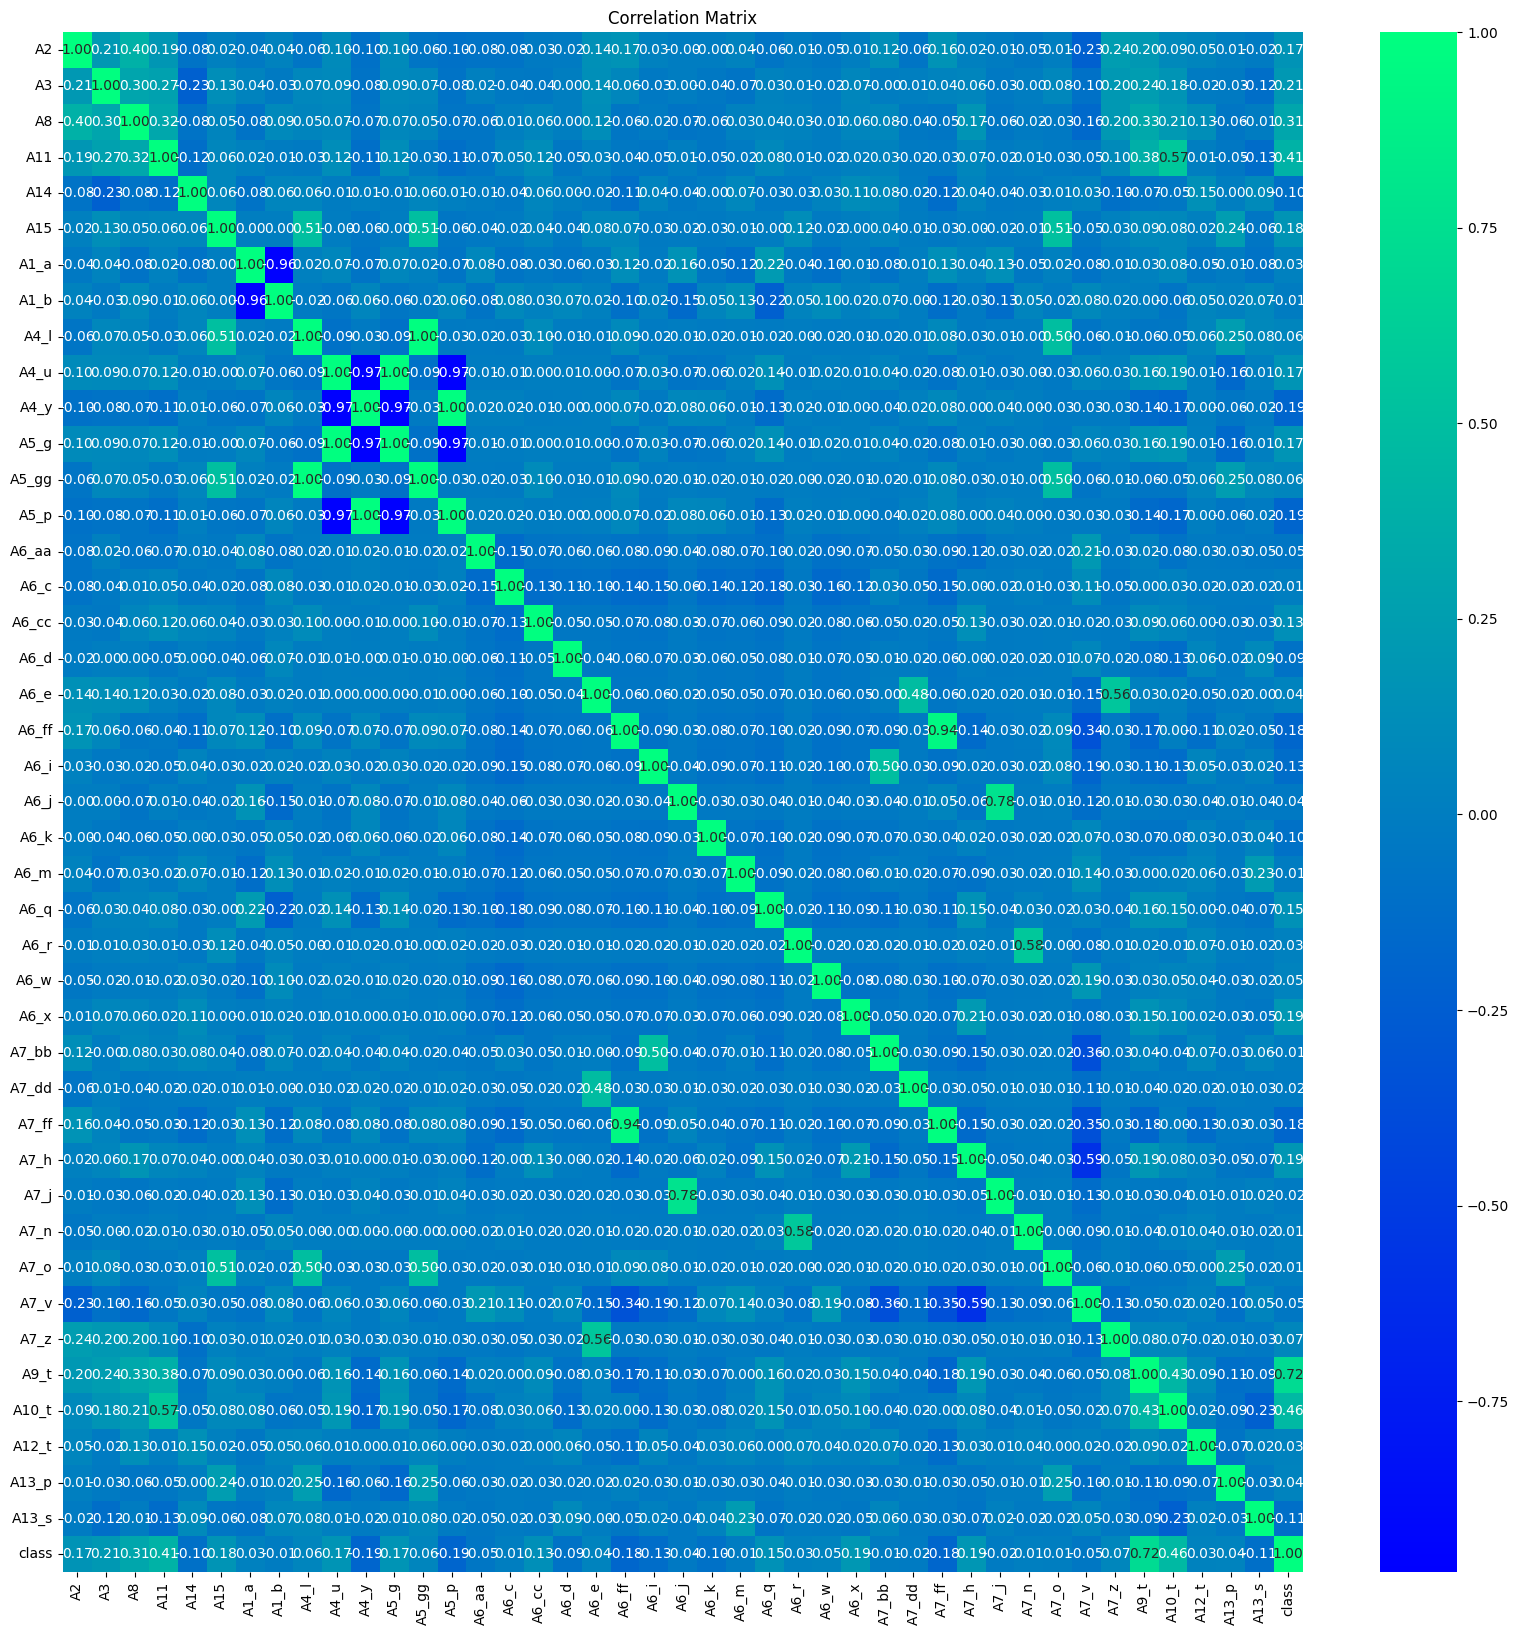

In [34]:

#move credit to the end for better readability of the corr matix
credit_encoded = credit_encoded[[c for c in credit_encoded if c not in ['class']] + ['class']]

X = credit_encoded.drop('class', axis=1)
y = credit_encoded['class']

corr_matrix = credit_encoded.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='winter', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()



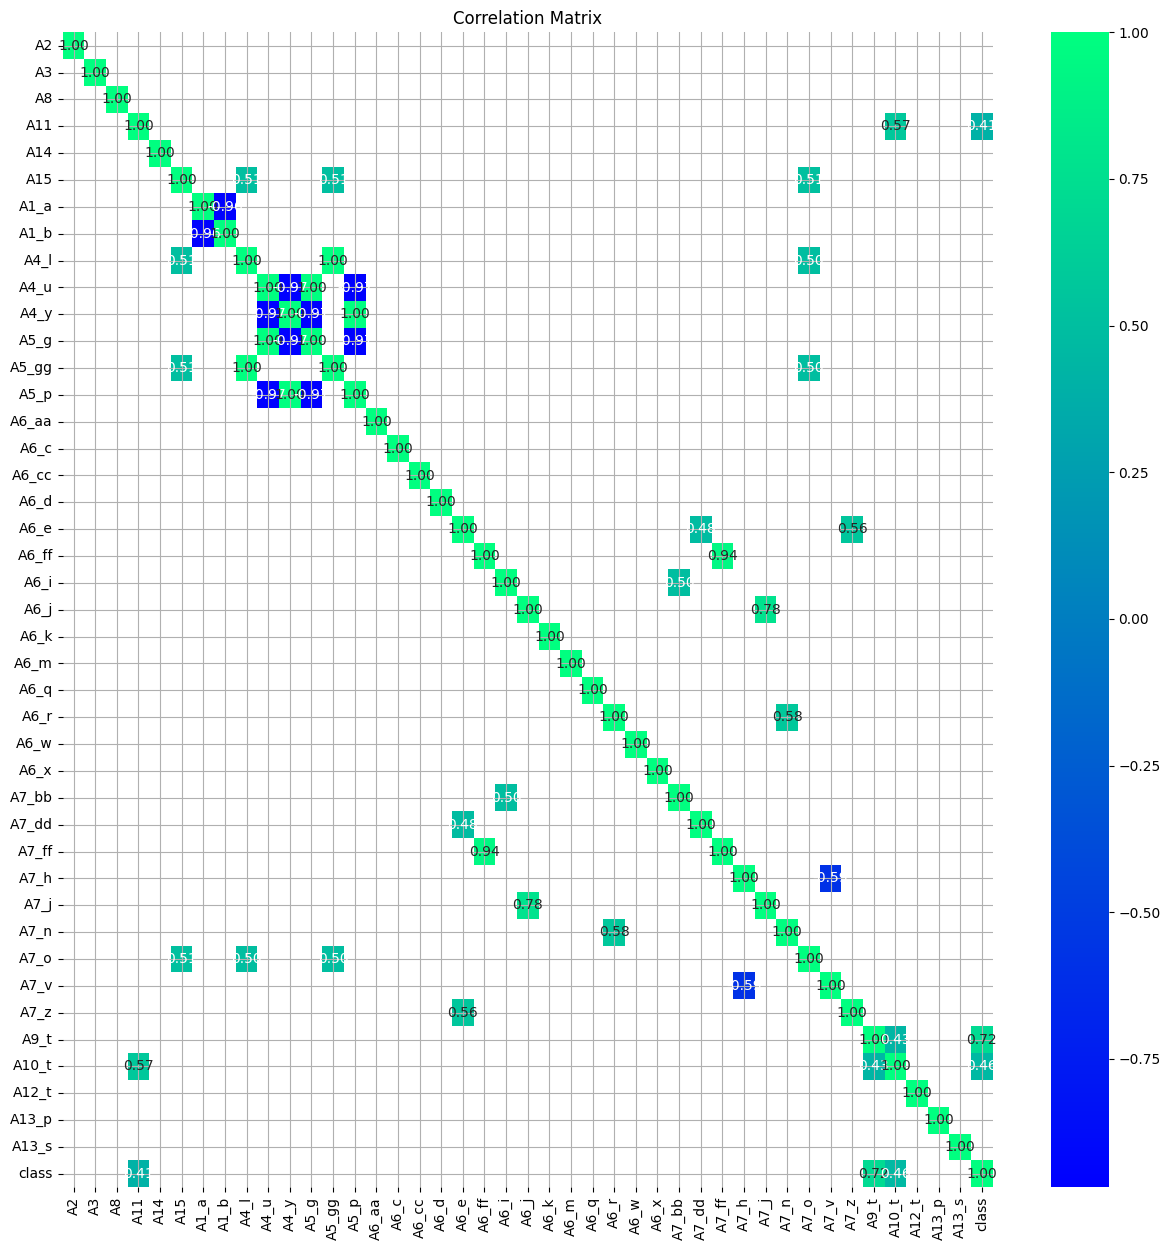

In [35]:
#matrix is too big to see clearly so we can adjust it to only show the values that are above a certain correlation value
corr_matrix = credit_encoded.corr()
corr_matrix[np.abs(corr_matrix) < 0.4] = np.nan
plt.figure(figsize=(15, 15))
plt.grid(True)
sns.heatmap(corr_matrix, annot=True, cmap='winter', fmt='.2f', mask=np.isnan(corr_matrix))
plt.title('Correlation Matrix')
plt.show()


In [36]:
X.shape

(690, 42)

Based on this correlation matrix, we can see that some of the columns might be redundant and might potentially cause overcomplication without contributing much or even cause multicolinearity. 

In [37]:
#we'll drop the columns that have a correlation of 0.75 or higher
redundant = ['A5_g', 'A4_y', 'A1_b', 'A5_gg', 'A7_j', 'A5_p', 'A7_ff']

credit_encoded.drop(X[redundant], axis=1, inplace=True)
X = credit_encoded.drop('class', axis=1)

In [38]:
#here we will standardize the data to make it easier for the model to learn after splitting it 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA


#now we use PCA to make the data easier to reduce the number of features
#might not be necessary 
#X_pca = PCA(n_components=5).fit_transform(X_scaled)
#X_pca = PCA(n_components=5).fit_transform(X_scaled)

split = {
    '20_80': (0.2, 0.8),
    '50_50': (0.5, 0.5),
    '80_20': (0.8, 0.2),
    '90_10': (0.9, 0.1),

}
y = credit_encoded['class']
train_size, test_size = split['20_80']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y)
#scale numeric data
scale = StandardScaler()
X_train = scale.fit_transform(X_train[numeric])
X_test = scale.transform(X_test[numeric])

# we'll balance the data by oversampling the minority class
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

#now we use PCA to make the data easier to reduce the number of features
#might not be necessary (not good for this dataset
X_test = PCA(n_components=2).fit_transform(X_test)
X_train = PCA(n_components=2).fit_transform(X_train)



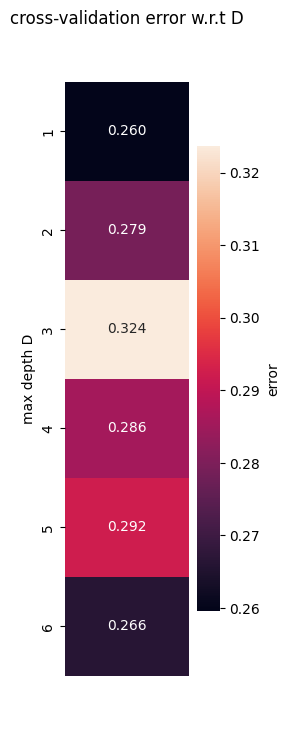

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn import tree

estimator = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
D_list = list(range(1, 7))

param_grid = {'max_depth': D_list}

grid_search = GridSearchCV(estimator, param_grid, cv=5, n_jobs=-1, scoring='accuracy')

grid_search.fit(X_train, y_train)

def draw_heatmap(errors, D_list, title):
    plt.figure(figsize = (2,9))
    ax = sns.heatmap(errors, annot=True, fmt='.3f', yticklabels=D_list, xticklabels=[])
    ax.collections[0].colorbar.set_label('error')
    ax.set(ylabel='max depth D')
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
    plt.title(title)
    plt.show()

cross_val_errors = 1 - grid_search.cv_results_['mean_test_score'].reshape(-1,1)
draw_heatmap(cross_val_errors, D_list, title='cross-validation error w.r.t D')

Now, we are ready to train and test our models on the data. 

In [40]:
#import random forest classifier and svc 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

classifiers_credit = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=20),
        'params': {
            'n_estimators': [ 200, 400],
            'criterion': ['entropy'],
            'max_depth': [10],
            'min_samples_split': [6],
            'min_samples_leaf': [5],
            'max_features': ['sqrt']
        }
    },
    'SVM': {
        'model': SVC(random_state=20),
        'params': {
            'C': [5],
            'kernel': ['rbf'],
            'gamma': [0.0005],
            'probability': [True]
        }
    },
    'LogisticRegression' : {   
        'model' : LogisticRegression(random_state=20),
        'params': {
            'C': [1.0],
            'max_iter': [100],
            'solver': ['lbfgs', 'liblinear']
        }
    }
}

In [41]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold

results = []

for name, info in classifiers_credit.items():
    print(f"Training {name}...")
    
    grid = GridSearchCV(info['model'], info['params'], cv=10, scoring='accuracy', n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=20)
    train_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
    test_scores = cross_val_score(best_model, X_test, y_test, cv=cv, scoring='accuracy')
    
    y_train_prob = best_model.predict_proba(X_train)
    train_loss = log_loss(y_train, y_train_prob)
    
    y_test_prob = best_model.predict_proba(X_test)
    test_loss = log_loss(y_test, y_test_prob)
    
    results.append({
        'Classifier': name,
        'Best Parameters': best_params,
        'Training Accuracy': train_scores.mean(),
        'Testing Accuracy': test_scores.mean(),
        'Training Loss': train_loss,
        'Testing Loss': test_loss
    })
    
    print(f"{name} Best Parameters: {best_params}")
    print(f"{name} Training Accuracy: {train_scores.mean():.4f}")
    print(f"{name} Testing Accuracy: {test_scores.mean():.4f}")
    print(f"{name} Training Loss (Log Loss): {train_loss:.4f}")
    print(f"{name} Testing Loss (Log Loss): {test_loss:.4f}\n")

Training RandomForest...
RandomForest Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 200}
RandomForest Training Accuracy: 0.6829
RandomForest Testing Accuracy: 0.7048
RandomForest Training Loss (Log Loss): 0.3578
RandomForest Testing Loss (Log Loss): 0.6234

Training SVM...
SVM Best Parameters: {'C': 5, 'gamma': 0.0005, 'kernel': 'rbf', 'probability': True}
SVM Training Accuracy: 0.5796
SVM Testing Accuracy: 0.6231
SVM Training Loss (Log Loss): 0.6168
SVM Testing Loss (Log Loss): 0.6506

Training LogisticRegression...
LogisticRegression Best Parameters: {'C': 1.0, 'max_iter': 100, 'solver': 'lbfgs'}
LogisticRegression Training Accuracy: 0.7087
LogisticRegression Testing Accuracy: 0.7103
LogisticRegression Training Loss (Log Loss): 0.5649
LogisticRegression Testing Loss (Log Loss): 0.6167



In [43]:
import matplotlib.pyplot as plt
import pandas as pd

def make_graph(results):
    results_df = pd.DataFrame(results)

    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Classifier'], results_df['Training Accuracy'], label='Training Accuracy', color='orange', marker='o')
    plt.plot(results_df['Classifier'], results_df['Testing Accuracy'], label='Testing Accuracy', color='blue', marker='o')
    plt.title('Training vs Testing Accuracy')
    plt.ylabel('Accuracy')
    plt.grid(axis='y')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Classifier'], results_df['Training Loss'], label='Training Log Loss', marker='o')
    plt.plot(results_df['Classifier'], results_df['Testing Loss'], label='Testing Log Loss',marker='o')
    plt.title('Training vs Testing Log Loss')
    plt.ylabel('Log Loss')=
    plt.grid(axis='y')
    plt.legend()
    plt.show()

make_graph(results)



SyntaxError: cannot assign to function call (2745482652.py, line 20)

This database encodes the complete set of possible board configurations at the end of tic-tac-toe games, where "x" is assumed to have played first.  The target concept is "win for x" (i.e., true when "x" has one of 8 possible ways to create a "three-in-a-row").  

In [ ]:
path = 'data/TicTacTo/tic-tac-toe.data'
col_names = [str(i) for i in range(1, 10)] + ['class']
game=pd.read_csv(path, names=col_names)
game.head()


Now we check for missing/NaN values and see how many unique values the data has 

In [ ]:
def unique_data(data):
    for col in data.columns:
        print(f'{col}: {data[col].unique()}')

unique_data(game)

def check_missing(data):
    print(data.isna().sum())
    print(data.isnull().sum())
    print(data.isin(['?']).sum())

check_missing(game)


Let's make all the data numerical

In [ ]:

#replace positive and negative with 1 and -1
game['class'].replace({'positive': 1, 'negative': -1}, inplace=True)


# we'll encode the categorical values using one-hot encoding
categoric = [str(i) for i in range(1, 10)]
game = pd.get_dummies(game, columns=categoric, drop_first=True)
game = game.astype(int)
game.head()


In [ ]:
X = game.drop('class', axis=1)
y = game['class']

corr_matrix = game.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='winter', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

we see that most of the features are independent of eachother.

In [ ]:
# we now noramalize the data after splitting it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=20, stratify=y)

scale = StandardScaler()
X_train= scale.fit_transform(X_train)  
X_test= scale.fit_transform(X_test)



#we'll use a decision tree classifier to classify the data
grid_search.fit(X_train, y_train)
cross_val_errors = 1 - grid_search.cv_results_['mean_test_score'].reshape(-1,1)
draw_heatmap(cross_val_errors, D_list, title='cross-validation error w.r.t D')



In [ ]:
#visualize the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 20))
plot_tree(grid_search.best_estimator_, filled=True, feature_names=game.columns)
plt.show()



In [ ]:
classifiers_ttt = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=20),
        'params': {
            'n_estimators': [200],
            'criterion': ['gini', 'entropy'],
            'max_depth': [10],
            'min_samples_split': [5],
            'min_samples_leaf': [3],
            'max_features': ['log2']
        }
    },
    'SVM': {
        'model': SVC(random_state=20),
        'params': {
            'C': [ 1, 10],
            'kernel': ['rbf'],
            'gamma': [0.01],
            'probability': [True]
        }
    },
    'LogisticRegression' : {   
        'model' : LogisticRegression(random_state=20),
        'params': {
            'C': [1.5],
            'max_iter': [75, 100, 500, 1000],
            'solver': ['lbfgs', 'liblinear']
        }
    }
}

In [ ]:
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold

results = []

for name, info in classifiers_ttt.items():
    print(f"Training {name}...")
    
    grid = GridSearchCV(info['model'], info['params'], cv=10, scoring='accuracy', n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)
    train_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
    test_scores = cross_val_score(best_model, X_test, y_test, cv=cv, scoring='accuracy')
    
    y_train_prob = best_model.predict_proba(X_train)
    train_loss = log_loss(y_train, y_train_prob)
    
    y_test_prob = best_model.predict_proba(X_test)
    test_loss = log_loss(y_test, y_test_prob)
    
    results.append({
        'Classifier': name,
        'Best Parameters': best_params,
        'Training Accuracy': train_scores.mean(),
        'Testing Accuracy': test_scores.mean(),
        'Training Loss': train_loss,
        'Testing Loss': test_loss
    })
    
    print(f"{name} Best Parameters: {best_params}")
    print(f"{name} Training Accuracy: {train_scores.mean():.4f}")
    print(f"{name} Testing Accuracy: {test_scores.mean():.4f}")
    print(f"{name} Training Loss (Log Loss): {train_loss:.4f}")
    print(f"{name} Testing Loss (Log Loss): {test_loss:.4f}\n")

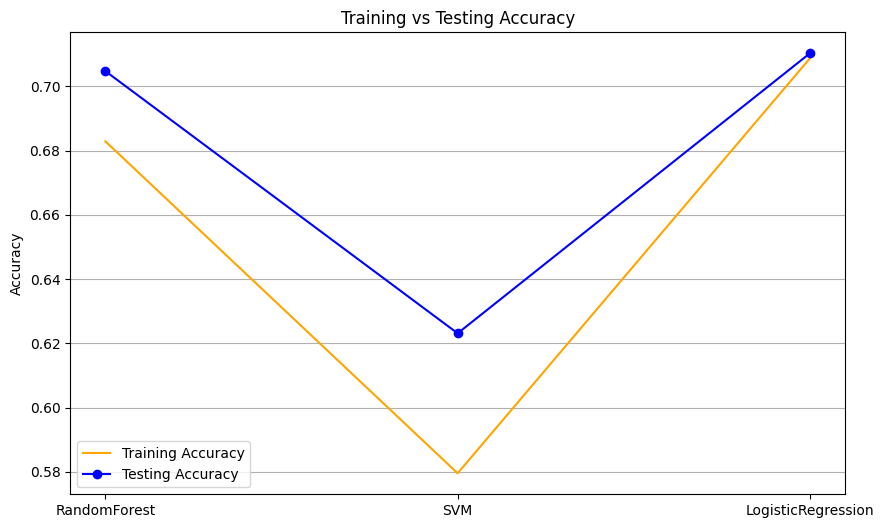

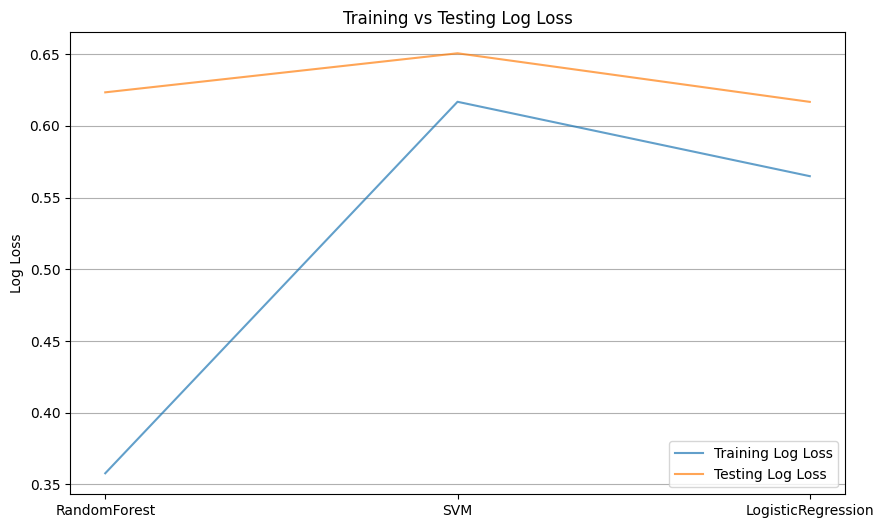

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

def make_graph(results):
    results_df = pd.DataFrame(results)

    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Classifier'], results_df['Training Accuracy'], label='Training Accuracy', color='orange')
    plt.plot(results_df['Classifier'], results_df['Testing Accuracy'], label='Testing Accuracy', color='blue', marker='o')
    plt.title('Training vs Testing Accuracy')
    plt.ylabel('Accuracy')
    plt.grid(axis='y')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Classifier'], results_df['Training Loss'], label='Training Log Loss', alpha=0.7)
    plt.plot(results_df['Classifier'], results_df['Testing Loss'], label='Testing Log Loss', alpha=0.7)
    plt.title('Training vs Testing Log Loss')
    plt.ylabel('Log Loss')
    plt.grid(axis='y')
    plt.legend()
    plt.show()

make_graph(results)



Analysis for paper: 

Now we will move on to our last dataset. The Wisconcin Breast Cancer dataset. 

In [ ]:
cancer = pd.read_csv('data/cancer/breast-cancer-wisconsin.data', header=None)
cancer.columns = [str(i) for i in range(1, 11)] + ['class']
cancer.head()
cancer.drop('1', axis=1, inplace=True)
cancer.head(  )



In [ ]:
unique_data(cancer)


In [ ]:
#fix missing and invalid values

check_missing(cancer)
cancer.replace('?', np.nan, inplace=True)
#class = 2 for benign and 4 for malignant
cancer['class'].replace({2: -1, 4: 1}, inplace=True)
unique_data(cancer)




In [ ]:
#no encoding needed 
X = cancer.drop('class', axis=1)
y = cancer['class']

corr_matrix = cancer.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='winter', fmt='.2f')
plt.title('Correlation Matrix')


In [ ]:
#we can drop a few columns that might cause multicollinearity
redundant = ['3', '7','4']
cancer.drop(redundant, axis=1, inplace=True)
X = cancer.drop('class', axis=1)


In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(cancer.corr(), annot=True, cmap='winter', fmt='.2f')
plt.title('Correlation Matrix')

let's see if the data is skewed a lot. if so, we can balance it out.

In [ ]:
#distribution of the classes
sns.countplot(x='class', data=cancer)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()


We have to balance the data after splitting to get rid of the skew. 


In [ ]:
#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y)

#scale the data
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.fit_transform(X_test)

#balance the data
from imblearn.over_sampling import SMOTE
#smote = SMOTE(sampling_strategy='minority')
#X_train, y_train = smote.fit_resample(X_train, y_train)


In [ ]:
#lets check the distribution of the classes after balancing
sns.countplot(x=y_train)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

In [ ]:
#use a decision tree classifier to see the depth that gives the best accuracy
grid_search.fit(X_train, y_train)
cross_val_errors = 1 - grid_search.cv_results_['mean_test_score'].reshape(-1,1)
draw_heatmap(cross_val_errors, D_list, title='cross-validation error w.r.t D')


In [ ]:
classifiers_cancer = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=20),
        'params': {
            'n_estimators': [150],
            'criterion': ['gini', 'entropy'],
            'max_depth': [6],
            'min_samples_split': [5],
            'min_samples_leaf': [5],
            'max_features': ['log2']
        }
    },
    'SVM': {
        'model': SVC(random_state=20),
        'params': {
            'C': [ 1, 10],
            'kernel': ['rbf'],
            'gamma': [0.01],
            'probability': [True]
        }
    },
    'LogisticRegression' : {   
        'model' : LogisticRegression(random_state=20),
        'params': {
            'C': [1.5],
            'max_iter': [75, 100, 500, 1000],
            'solver': ['lbfgs', 'liblinear'],
            'penalty': ['l2']
        }
    }
}

In [ ]:


results = []

for name, info in classifiers_cancer.items():
    print(f"Training {name}...")
    
    grid = GridSearchCV(info['model'], info['params'], cv=10, scoring='accuracy', n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=20)
    train_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
    test_scores = cross_val_score(best_model, X_test, y_test, cv=cv, scoring='accuracy')
    
    y_train_prob = best_model.predict_proba(X_train)
    train_loss = log_loss(y_train, y_train_prob)
    
    y_test_prob = best_model.predict_proba(X_test)
    test_loss = log_loss(y_test, y_test_prob)
    
    results.append({
        'Classifier': name,
        'Best Parameters': best_params,
        'Training Accuracy': train_scores.mean(),
        'Testing Accuracy': test_scores.mean(),
        'Training Loss': train_loss,
        'Testing Loss': test_loss
    })
    
    print(f"{name} Best Parameters: {best_params}")
    print(f"{name} Training Accuracy: {train_scores.mean():.4f}")
    print(f"{name} Testing Accuracy: {test_scores.mean():.4f}")
    print(f"{name} Training Loss (Log Loss): {train_loss:.4f}")
    print(f"{name} Testing Loss (Log Loss): {test_loss:.4f}\n")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def make_graph(results):
    results_df = pd.DataFrame(results)

    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Classifier'], results_df['Training Accuracy'], label='Training Accuracy', color='orange', marker='o')
    plt.plot(results_df['Classifier'], results_df['Testing Accuracy'], label='Testing Accuracy', color='blue', marker='o')
    plt.title('Training vs Testing Accuracy')
    plt.ylabel('Accuracy')
    plt.grid(axis='y')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Classifier'], results_df['Training Loss'], label='Training Log Loss')
    plt.plot(results_df['Classifier'], results_df['Testing Loss'], label='Testing Log Loss')
    plt.title('Training vs Testing Log Loss')
    plt.ylabel('Log Loss')
    plt.grid(axis='y')
    plt.legend()
    plt.show()

make_graph(results)

